# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#be3e3a">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
| Group            | X       |
|------------------|---------|
| Daniel Kolev     | 6160255 |
| Zain Qureshi     | 6143555 |
| Deyan Papazov    | 6191150 |
| Dragostin Ivanov | 6159737 |

</div>

#### Imports

In [194]:
import matplotlib.pyplot as plt
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import softmax

#### Loading the data

In [195]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

## 1 Questions
### 1.2 Architecture
#### Question 1:

We will now start with implementing our perceptron. We will create a Perceptron class which will store the functionality

In [196]:
class Perceptron:

    def __init__(self, dimensions):
        self.dimensions = dimensions
        self.w = np.random.rand(dimensions)
        self.b = np.random.rand()

    def predict(self, x):
        return np.where(np.dot(x, self.w) + self.b >= 0, 1, 0)

    def train(self, X, Y, epochs=1000, learning_rate=0.05):
        for i in range(epochs):
            for x, y in zip(X, Y):
                loss = y - self.predict(x)
                self.w = [ self.w[i] + learning_rate*x[i]*loss for i in range(self.dimensions) ]
                self.b = self.b + learning_rate*loss

def accuracy(labels, predicted):
    return np.mean(np.where(labels == predicted, 1, 0))


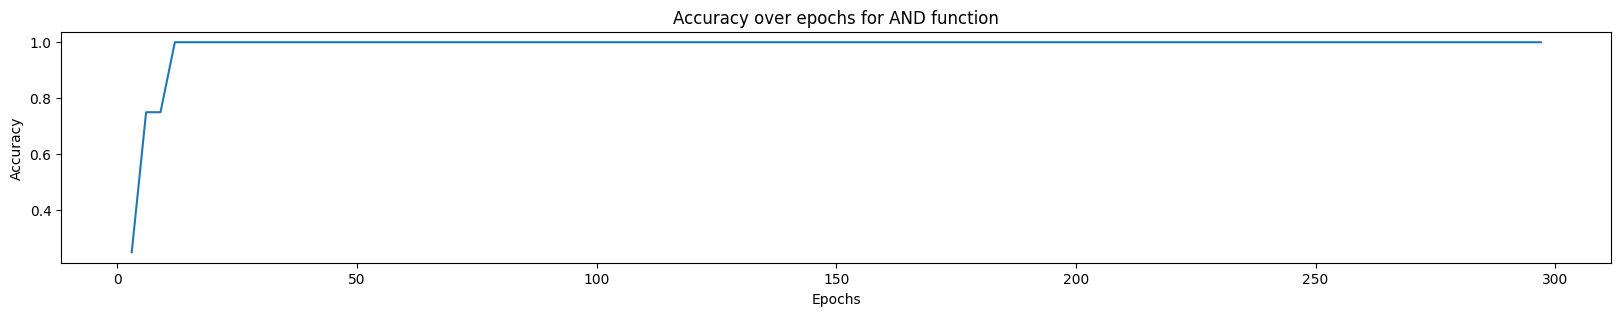

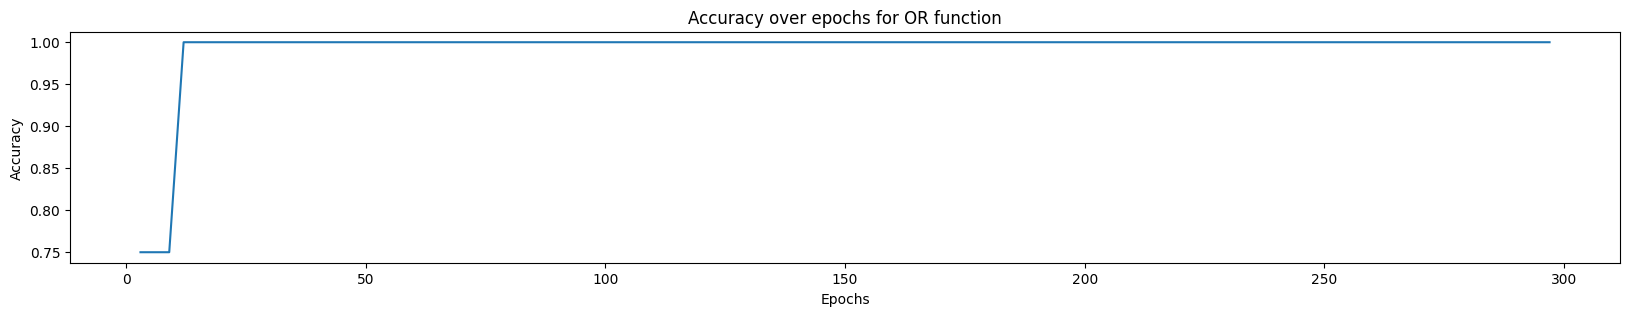

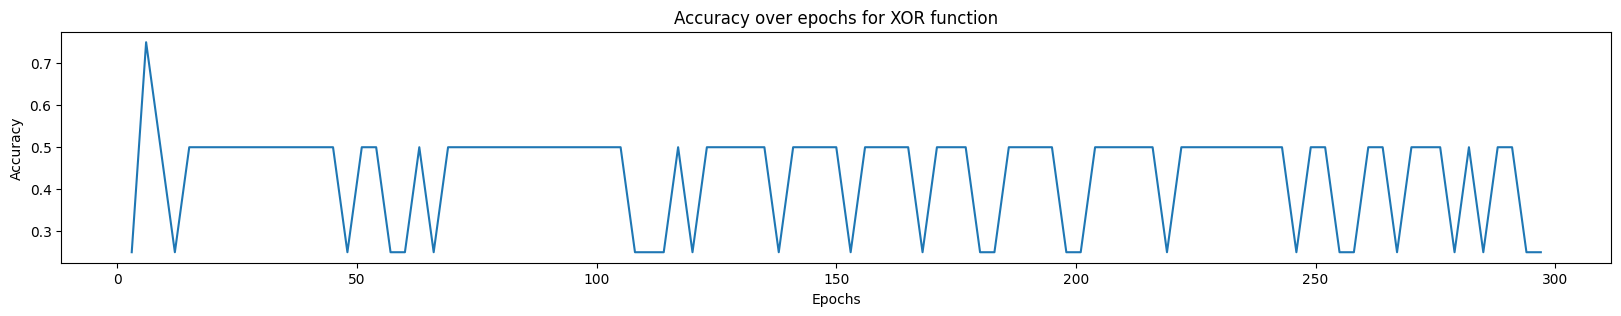

In [197]:
q1_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
q1_and_labels = np.array([0, 0, 0, 1])
q1_or_labels = np.array([0, 1, 1, 1])
q1_xor_labels = np.array([0, 1, 1, 0])

# Make the figures for the AND, OR, and XOR functions
# next to each other

def plot_error_over_epochs(X, Y, title="Accuracy over epochs"):
    epoch_numbers = [3 * i for i in range(1, 100)]
    accuracies = []
    for epoch_number in epoch_numbers:
        p = Perceptron(2)
        p.train(X, Y, epochs=epoch_number)
        accuracies.append(accuracy(p.predict(X), Y))

    plt.figure(figsize=(20, 3))
    plt.plot(epoch_numbers, accuracies)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.show()

plot_error_over_epochs(q1_train, q1_and_labels, title="Accuracy over epochs for AND function")
plot_error_over_epochs(q1_train, q1_or_labels, title="Accuracy over epochs for OR function")
plot_error_over_epochs(q1_train, q1_xor_labels, title="Accuracy over epochs for XOR function")

<div style="background-color:#f1be3e">
_Put your code blocks above (if any) and write your answer here._
</div>

### The Perceptron
We have created a simple Perceptron class.
On initialisation, you must specify the dimensionality of the input data for the perceptron.
Using the `train` method you can train the perceptron on a given dataset X with labels Y. You can optionally specify the number of epochs and the learning rate.
Using the `predict` method you can use the trained perceptron on a dataset X to get the predicted labels.

We have also plotted the accuracy of the Perceptron over the number of training epochs for the AND, OR, and XOR operations. We can see that the Perceptron eventually (around epoch>20) learns the AND and OR operations, but it always fluctuates when it comes to the XOR operation.

This is because the AND and OR operations are linearly separable, where the XOR isn't. The Perceptron can only learn linear relationships and so it will never be able to learn the XOR operation.



T#### Question 2

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

We need 10 input neurons because our input data has 10 features and we need to feed all of them to make a prediction about the class label of that row.

#### Question 3

<div style="background-color:#f1be3e">

_Write your answer here._

</div>
We require 7 output neurons because our classification task has 7 labels to pick from. Each output neuron will represent the probability that our row belongs in the corresponding class.

#### Question 4

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

By the universal approximation theorem 1 layer is enough for any classification task. So initially we will use only a single layer with say double the neurons of the input layer. So 1 hidden layer with 20 neurons.

#### Question 5

<div style="background-color:#f1be3e">

_Write your answer here._

</div>
Since we have only 1 layer we need only 1 activation function. Since we want to see probabilities in the output layer, we are going to use the Sigmoid activation function to get values in the range (0, 1).

#### Question 6

<div style="background-color:#f1be3e">

_Write your answer here. You can include images using the syntax !.[title].(filepath), removing decimal points therein._

</div>

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [198]:
class Linear:
    def __init__(self, in_features, out_features, init_strategy="zeros"):

        if init_strategy == "normal":
            mu, sigma = 0, 1
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features)) # (d,k)
        elif init_strategy == "xavier":
            mu, sigma = 0, np.sqrt(1/in_features)
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features))
        elif init_strategy == "he":
            mu, sigma = 0, np.sqrt(2/in_features)
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features))
        else:
            self.weight = np.zeros(shape=(in_features, out_features))

        self.bias = np.zeros(out_features) # (k,)

        self.cache = None
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        self.cache = x # (n,d)
        return x @ self.weight + self.bias # (n,d)(d,k) + (k,) = (n,k) + (n,k) broadcasted = (n,k)
    
    def backward(self, dupstream):
       # dupstream is (n,k)
        self.weight_grad = self.cache.T @ dupstream # (d,n)(n,k) = (d,k)
        self.bias_grad = np.sum(dupstream, axis=0) #(n,k) sum axis 0 = (k,)
        return dupstream @ self.weight.T # (n,k)(k,d) = (n,d)

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [199]:
class Sigmoid:

    def apply(self, x):
        return 1 / (1 + np.exp(-x))

    def apply_derivative(self, x):
        return self.apply(x) * (1 - self.apply(x))

In [200]:
class ReLU:

    def apply(self, x):
        return np.maximum(0, x)

    def apply_derivative(self, x):
        return np.where(x <= 0, 0, 1)

In [201]:
class Activation:
    def __init__(self, function):
        self.cache = None
        self.function = function
    
    def forward(self, x):
        self.cache = x #(n,k)
        return self.function.apply(x) #(n,k)
    
    def backward(self, dupstream):
        # dupstream is (n,k)
        return dupstream * self.function.apply_derivative(self.cache) #(n,k) * C

In [202]:
class BinaryCrossEntropy:
    def value(self, labels, logits):
        eps = 1e-9  # numerical stability
        return -np.mean(labels * np.log(logits + eps) + (1 - labels) * np.log(1 - logits + eps))

    def grad(self, labels, logits):
        eps = 1e-9
        return (-labels / (logits + eps) + (1 - labels) / (1 - logits + eps)) / labels.shape[0]

In [203]:
class SoftmaxCrossEntropy:

    def softmax(self, logits):
        # Stable softmax taken from the web
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp = np.exp(shifted)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def value(self, labels, logits):
        n = logits.shape[0]
        probs = softmax(logits)
        log_likelihood = -np.log(probs[np.arange(n), labels])
        return np.mean(log_likelihood)

    def grad(self, labels, logits):
        n = logits.shape[0]
        probs = softmax(logits)
        log_likelihood = -np.log(probs[np.arange(n), labels])
        return np.mean(log_likelihood)


**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [204]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        logits = x
        for layer in self.layers:
            logits = layer.forward(logits)

        return logits
    
    def backward(self, dupstream):
        gradient = dupstream
        for layer in reversed(self.layers):
            gradient = layer.backward(gradient)
        return gradient
    
    def optimizer_step(self, lr):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad


**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [205]:
def train(net, inputs, labels, loss, mapToLabel, lr=0.1, epochs=1000):

    losses = []
    accuracies = []

    labels_reshaped = labels.reshape(labels.shape[0], 1)

    for epoch in range(epochs):

        logits = net.forward(inputs)
        loss_val = loss.value(labels_reshaped, logits)
        loss_grad = loss.grad(labels_reshaped, logits)
        acc = accuracy(labels_reshaped, mapToLabel(logits))

        net.backward(loss_grad)
        net.optimizer_step(lr)

        losses.append(loss_val)
        accuracies.append(acc)

    return losses, accuracies

### Implementation verification
We are going to verify the correctness of the neural network implementation before proceeding to find current bugs before we build further. First, we will test that it can learn the AND, OR, XOR operations, and then we will run a test on the products data set.

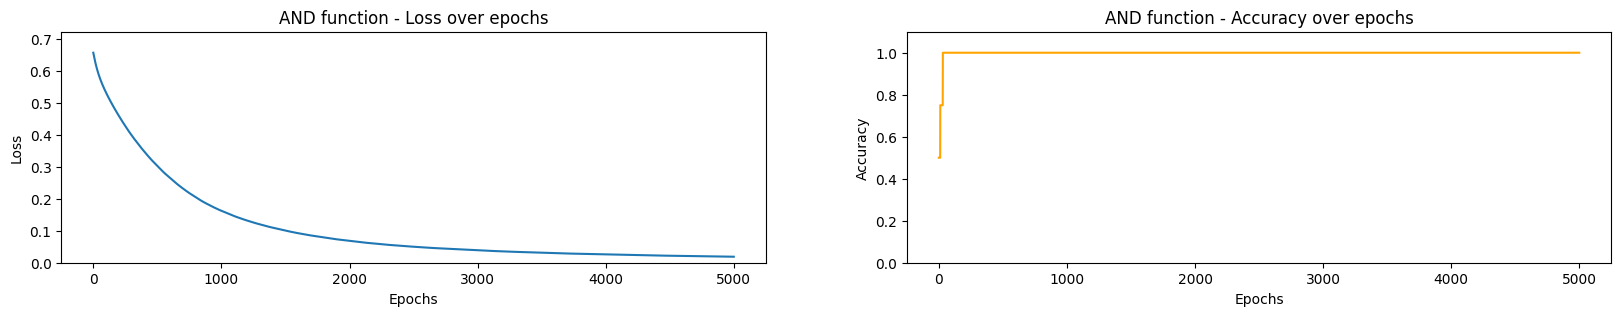

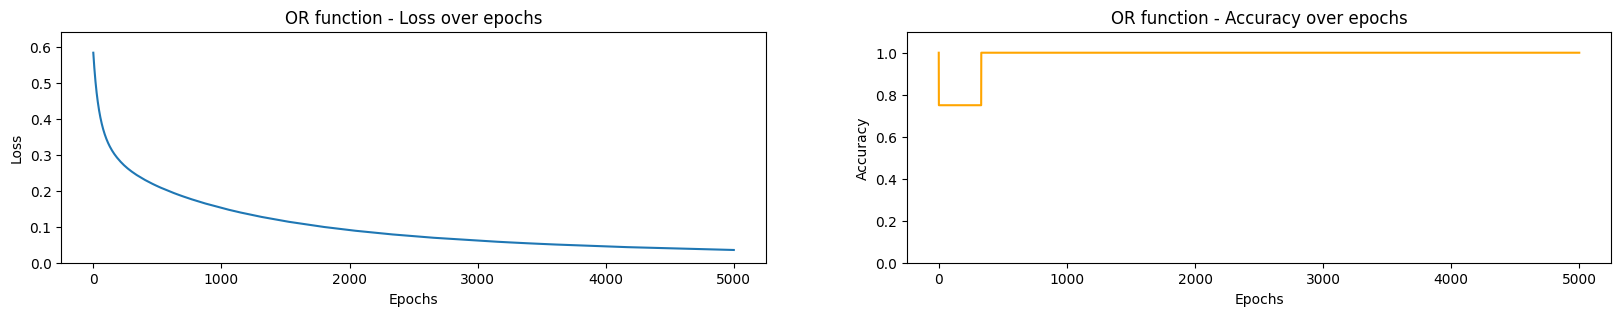

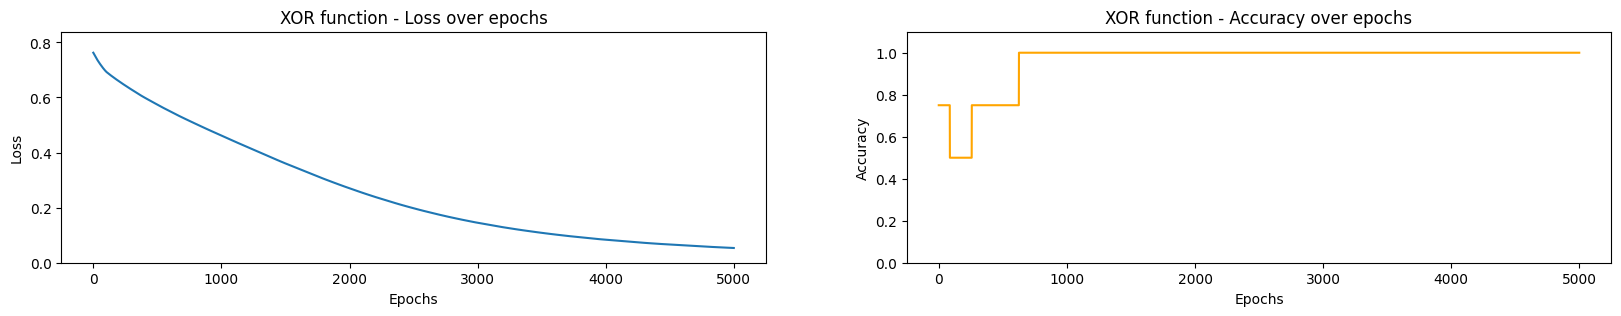

In [231]:
q1_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
q1_and_labels = np.array([0, 0, 0, 1])
q1_or_labels = np.array([0, 1, 1, 1])
q1_xor_labels = np.array([0, 1, 1, 0])


def plot_error_over_epochs(X, Y, title=""):

    np.random.seed(2399043)

    p = Network([Linear(2, 10, init_strategy="he"), Activation(ReLU()),
                 Linear(10, 1, init_strategy="xavier"), Activation(Sigmoid())])
    losses, accuracies = train(p, X, Y, BinaryCrossEntropy(), lambda x: np.where(x > 0.5, 1, 0), lr=0.01, epochs=5000)

    # Plot 2 figures, one for losses and one for accuracies
    # On the accuracy plot make it fixed height of 1
    fig, axes = plt.subplots(1, 2, figsize=(20, 3))
    axes[0].plot(losses)
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].set_ylim(0, max(losses) * 1.1)
    axes[0].set_title(title + " - Loss over epochs")

    axes[1].plot(accuracies, color="orange")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title(title + " - Accuracy over epochs")
    plt.show()

plot_error_over_epochs(q1_train, q1_and_labels, title="AND function")
plot_error_over_epochs(q1_train, q1_or_labels, title="OR function")
plot_error_over_epochs(q1_train, q1_xor_labels, title="XOR function")

In [ ]:



def plot_error_over_epochs(X, Y, title=""):

    np.random.seed(2399043)

    p = Network([Linear(2, 10, init_strategy="he"), Activation(ReLU()),
                 Linear(10, 1, init_strategy="xavier"), Activation(Sigmoid())])
    losses, accuracies = train(p, X, Y, BinaryCrossEntropy(), lambda x: np.where(x > 0.5, 1, 0), lr=0.01, epochs=5000)

    # Plot 2 figures, one for losses and one for accuracies
    # On the accuracy plot make it fixed height of 1
    fig, axes = plt.subplots(1, 2, figsize=(20, 3))
    axes[0].plot(losses)
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].set_ylim(0, max(losses) * 1.1)
    axes[0].set_title(title + " - Loss over epochs")

    axes[1].plot(accuracies, color="orange")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title(title + " - Accuracy over epochs")
    plt.show()

plot_error_over_epochs(q1_train, q1_and_labels, title="AND function")

#### Question 7

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 9

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.4 Optimization

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>